# Concept Exploration

It appears that from this one instance that a dummy-output appended to the training  CIFAR10 dataset output and an accompanying dummy-head (in the Model_11)improved early training when compared to the nearly-identical (same initialization) normal conv model (model_10).

The results are nearly identical after 10 epochs, however, model_11 arrived faster and outperformed from the very first epoch.

More runs would be needed to statistically prove the idea is conceptually sound. Theoretical analysis would be required to prove the concept is truthfully beneficial and in what context.

In [ ]:
# ============================================================
# Single-cell Colab script:
# CIFAR-10 CNN (10 outputs)  VS  identical CNN with 11th "fake"
# output used ONLY during training.
#
# - Models identical except output layer size (10 vs 11).
# - Shared layers have identical initialization (explicit weight copy).
# - 11th target is constant FAKE_CONSTANT during training.
# - Validation for the 11-output model evaluates ONLY real 10 classes.
# - Plots loss + accuracy side-by-side.
#
# Run this whole cell in Google Colab.
# ============================================================

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 1234
tf.keras.utils.set_random_seed(SEED)

# Determinism (GPU ops may still vary slightly depending on Colab runtime)
# NOTE: If OOM persists, comment this block out.
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

# -----------------------------
# Hyperparameters
# -----------------------------
EPOCHS = 10
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
FAKE_CONSTANT = 0.1  # fake label value for the 11th output (training only)

# -----------------------------
# Load + preprocess CIFAR-10
# -----------------------------
(x_train, y_train_int), (x_test, y_test_int) = tf.keras.datasets.cifar10.load_data()
y_train_int = y_train_int.squeeze().astype(np.int32)
y_test_int  = y_test_int.squeeze().astype(np.int32)

x_train = x_train.astype(np.float32) / 255.0
x_test  = x_test.astype(np.float32) / 255.0

num_classes = 10
y_train_10 = tf.one_hot(y_train_int, depth=num_classes).numpy().astype(np.float32)
y_test_10  = tf.one_hot(y_test_int,  depth=num_classes).numpy().astype(np.float32)

# Create 11-dim training targets with appended fake constant column
y_train_11 = np.concatenate(
    [y_train_10, np.full((y_train_10.shape[0], 1), FAKE_CONSTANT, dtype=np.float32)],
    axis=1
)
y_test_11 = np.concatenate(
    [y_test_10, np.full((y_test_10.shape[0], 1), FAKE_CONSTANT, dtype=np.float32)],
    axis=1
)

# -----------------------------
# Datasets (Optimized to prevent OOM/Restarts)
# -----------------------------
# We reduce buffer_size from 50,000 to 1,024 and add .cache()
# to prevent massive RAM spikes that crash Colab runtimes.

train_ds_10 = (
    tf.data.Dataset.from_tensor_slices((x_train, y_train_10))
    .cache()
    .shuffle(buffer_size=1024, seed=SEED, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
test_ds_10 = (
    tf.data.Dataset.from_tensor_slices((x_test, y_test_10))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

train_ds_11 = (
    tf.data.Dataset.from_tensor_slices((x_train, y_train_11))
    .cache()
    .shuffle(buffer_size=1024, seed=SEED, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
# test_ds_11 exists but we intentionally do NOT validate using the fake dim
test_ds_11 = (
    tf.data.Dataset.from_tensor_slices((x_test, y_test_11))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# -----------------------------
# Model definition
# -----------------------------
def build_small_cnn(num_outputs: int) -> tf.keras.Model:
    inputs = tf.keras.Input(shape=(32, 32, 3), name="image")

    x = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu", name="conv1")(inputs)
    x = tf.keras.layers.MaxPool2D(name="pool1")(x)

    x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu", name="conv2")(x)
    x = tf.keras.layers.MaxPool2D(name="pool2")(x)

    x = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu", name="conv3")(x)
    x = tf.keras.layers.GlobalAveragePooling2D(name="gap")(x)

    x = tf.keras.layers.Dense(128, activation="relu", name="dense1")(x)
    x = tf.keras.layers.Dropout(0.2, name="dropout")(x)

    # Sigmoid multi-label head:
    # lets us append a constant target column without "must-sum-to-1" constraints.
    outputs = tf.keras.layers.Dense(num_outputs, activation="sigmoid", name="head")(x)

    return tf.keras.Model(inputs=inputs, outputs=outputs, name=f"cnn_{num_outputs}_sigmoid")

model_10 = build_small_cnn(num_outputs=10)
model_11 = build_small_cnn(num_outputs=11)

# -----------------------------
# Force identical initialization for shared layers
# -----------------------------
name_to_layer_10 = {layer.name: layer for layer in model_10.layers}

for layer_11 in model_11.layers:
    layer_name = layer_11.name
    if layer_name in name_to_layer_10:
        layer_10 = name_to_layer_10[layer_name]
        weights_10 = layer_10.get_weights()
        weights_11 = layer_11.get_weights()

        if len(weights_10) > 0:
            same_shapes = [w.shape for w in weights_10] == [w.shape for w in weights_11]
            if same_shapes:
                layer_11.set_weights(weights_10)

# -----------------------------
# Metrics
# -----------------------------
def cifar10_accuracy_from_sigmoid(y_true, y_pred):
    # y_true can be 10-d or 11-d, we only use first 10 columns
    y_true_10 = y_true[:, :10]
    y_pred_10 = y_pred[:, :10]
    true_class = tf.argmax(y_true_10, axis=1)
    pred_class = tf.argmax(y_pred_10, axis=1)
    return tf.reduce_mean(tf.cast(tf.equal(true_class, pred_class), tf.float32))

bce = tf.keras.losses.BinaryCrossentropy()

# 10-output model can use standard Keras validation
model_10.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=bce,
    metrics=[cifar10_accuracy_from_sigmoid],
)

# 11-output model trains on 11-d targets (includes fake dim),
# BUT we will validate manually on the 10-d task only.
model_11.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=bce,
)

# -----------------------------
# Custom validation callback for 11-output model (10-class only)
# -----------------------------
class TenClassValidationCallback(tf.keras.callbacks.Callback):
    def __init__(self, validation_dataset_10):
        super().__init__()
        self.validation_dataset_10 = validation_dataset_10
        self.val_loss_10_only_list = []
        self.val_acc_10_only_list = []
        self.bce = tf.keras.losses.BinaryCrossentropy()

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        batch_losses = []
        correct_count = 0
        total_count = 0

        for batch_x, batch_y_10 in self.validation_dataset_10:
            batch_pred_11 = self.model(batch_x, training=False)
            batch_pred_10 = batch_pred_11[:, :10]

            batch_loss = self.bce(batch_y_10, batch_pred_10)
            batch_losses.append(float(batch_loss.numpy()))

            true_class = tf.argmax(batch_y_10, axis=1)
            pred_class = tf.argmax(batch_pred_10, axis=1)
            correct_count += int(tf.reduce_sum(tf.cast(true_class == pred_class, tf.int32)).numpy())
            total_count += int(batch_y_10.shape[0])

        val_loss_10_only = float(np.mean(batch_losses))
        val_acc_10_only = float(correct_count / total_count)

        self.val_loss_10_only_list.append(val_loss_10_only)
        self.val_acc_10_only_list.append(val_acc_10_only)

        # Put into logs so History captures it
        logs["val_loss_10_only"] = val_loss_10_only
        logs["val_acc_10_only"] = val_acc_10_only

        print(f" — val_loss_10_only: {val_loss_10_only:.4f} — val_acc_10_only: {val_acc_10_only:.4f}")

# -----------------------------
# Train both models
# -----------------------------
print("\n==============================")
print("Training 10-output model")
print("==============================")
hist_10 = model_10.fit(
    train_ds_10,
    validation_data=test_ds_10,
    epochs=EPOCHS,
    verbose=2,
)

print("\n==============================")
print("Training 11-output model (fake dim in training only)")
print("==============================")
ten_val_cb = TenClassValidationCallback(test_ds_10)

hist_11 = model_11.fit(
    train_ds_11,
    epochs=EPOCHS,
    verbose=2,
    callbacks=[ten_val_cb],
)

# -----------------------------
# Final evaluation (10-class only)
# -----------------------------
print("\n==============================")
print("Final evaluation (10-class only)")
print("==============================")

test_loss_10, test_acc_10 = model_10.evaluate(test_ds_10, verbose=0)

# For model_11: compute loss + accuracy on first 10 outputs only
bce_eval = tf.keras.losses.BinaryCrossentropy()
correct_count = 0
total_count = 0
losses = []

for batch_x, batch_y_10 in test_ds_10:
    batch_pred_11 = model_11(batch_x, training=False)
    batch_pred_10 = batch_pred_11[:, :10]

    losses.append(float(bce_eval(batch_y_10, batch_pred_10).numpy()))

    true_class = tf.argmax(batch_y_10, axis=1)
    pred_class = tf.argmax(batch_pred_10, axis=1)
    correct_count += int(tf.reduce_sum(tf.cast(true_class == pred_class, tf.int32)).numpy())
    total_count += int(batch_y_10.shape[0])

test_loss_11_10_only = float(np.mean(losses))
test_acc_11_10_only = float(correct_count / total_count)

print(f"10-output model:  test_loss={test_loss_10:.4f}, test_acc={test_acc_10:.4f}")
print(f"11-output model:  test_loss_10_only={test_loss_11_10_only:.4f}, test_acc_10_only={test_acc_11_10_only:.4f}")

# -----------------------------
# Plot learning curves
# -----------------------------
epochs_10 = np.arange(1, len(hist_10.history["loss"]) + 1)
epochs_11 = np.arange(1, len(hist_11.history["loss"]) + 1)

train_loss_10 = np.array(hist_10.history["loss"], dtype=float)
val_loss_10   = np.array(hist_10.history["val_loss"], dtype=float)
train_acc_10  = np.array(hist_10.history["cifar10_accuracy_from_sigmoid"], dtype=float)
val_acc_10    = np.array(hist_10.history["val_cifar10_accuracy_from_sigmoid"], dtype=float)

train_loss_11 = np.array(hist_11.history["loss"], dtype=float)  # includes fake dim
val_loss_11_10_only = np.array(ten_val_cb.val_loss_10_only_list, dtype=float)
val_acc_11_10_only  = np.array(ten_val_cb.val_acc_10_only_list, dtype=float)

plt.figure(figsize=(12, 4))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs_10, train_loss_10, label="Train loss (10)")
plt.plot(epochs_10, val_loss_10,   label="Val loss (10)")
plt.plot(epochs_11, train_loss_11, label="Train loss (11; includes fake)")
plt.plot(epochs_11, val_loss_11_10_only, label="Val loss (11; 10-only)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs_10, train_acc_10, label="Train acc (10)")
plt.plot(epochs_10, val_acc_10,   label="Val acc (10)")
plt.plot(epochs_11, val_acc_11_10_only, label="Val acc (11; 10-only)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()

plt.tight_layout()
plt.show()

# -----------------------------
# (Optional) Inspect fake output behavior on test set
# -----------------------------
fake_values = []
for batch_x, _ in test_ds_10:
    batch_pred_11 = model_11(batch_x, training=False).numpy()
    fake_values.append(batch_pred_11[:, 10])

fake_values = np.concatenate(fake_values, axis=0)
print("\n==============================")
print("Fake output neuron stats on test set")
print("==============================")
print(f"mean={fake_values.mean():.4f}, std={fake_values.std():.4f}, target_in_training={FAKE_CONSTANT}")


Training 10-output model
Epoch 1/10
391/391 - 142s - 362ms/step - cifar10_accuracy_from_sigmoid: 0.1970 - loss: 0.3149 - val_cifar10_accuracy_from_sigmoid: 0.3004 - val_loss: 0.2715
Epoch 2/10
391/391 - 118s - 301ms/step - cifar10_accuracy_from_sigmoid: 0.3316 - loss: 0.2649 - val_cifar10_accuracy_from_sigmoid: 0.4028 - val_loss: 0.2452
Epoch 3/10
391/391 - 108s - 277ms/step - cifar10_accuracy_from_sigmoid: 0.4100 - loss: 0.2440 - val_cifar10_accuracy_from_sigmoid: 0.4371 - val_loss: 0.2328
Epoch 4/10
391/391 - 106s - 270ms/step - cifar10_accuracy_from_sigmoid: 0.4484 - loss: 0.2322 - val_cifar10_accuracy_from_sigmoid: 0.4689 - val_loss: 0.2206
Epoch 5/10
391/391 - 110s - 283ms/step - cifar10_accuracy_from_sigmoid: 0.4814 - loss: 0.2217 - val_cifar10_accuracy_from_sigmoid: 0.5010 - val_loss: 0.2145
Epoch 6/10
391/391 - 137s - 350ms/step - cifar10_accuracy_from_sigmoid: 0.5100 - loss: 0.2117 - val_cifar10_accuracy_from_sigmoid: 0.5426 - val_loss: 0.2002
Epoch 7/10
391/391 - 111s - 283m

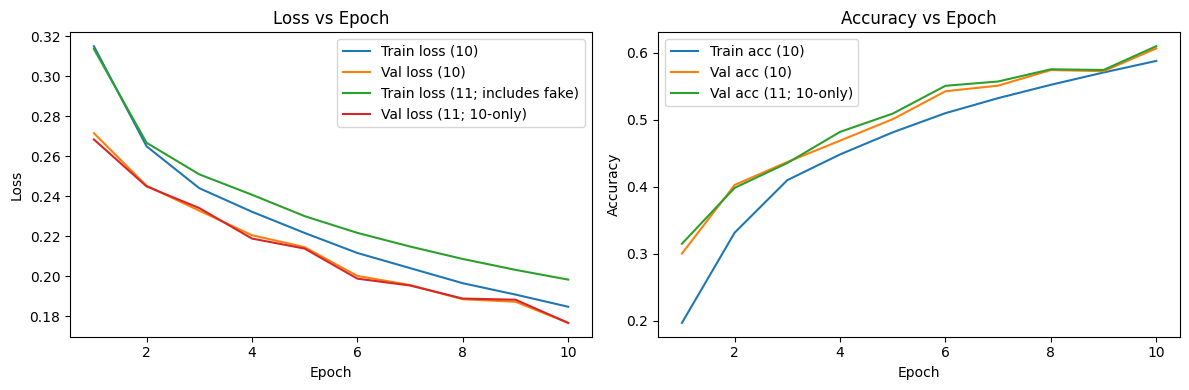


Fake output neuron stats on test set
mean=0.1123, std=0.0121, target_in_training=0.1
